MODELO: LDA
Exactitud (Accuracy): 0.8444444444444444

Matriz de Confusión:
 [[19  0  0]
 [ 0  8  5]
 [ 0  2 11]]

Reporte de Clasificación:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.80      0.62      0.70        13
   virginica       0.69      0.85      0.76        13

    accuracy                           0.84        45
   macro avg       0.83      0.82      0.82        45
weighted avg       0.85      0.84      0.84        45



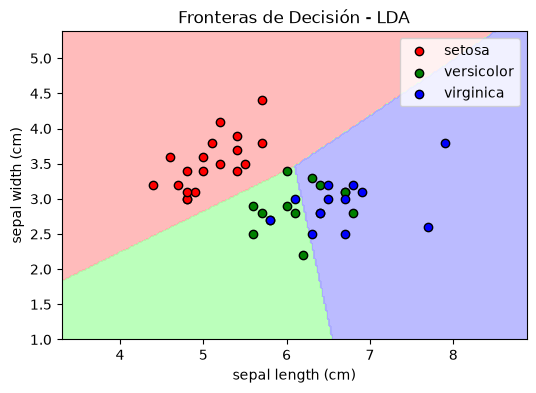

MODELO: K-NN (k=3)
Exactitud (Accuracy): 0.7555555555555555

Matriz de Confusión:
 [[19  0  0]
 [ 0  7  6]
 [ 0  5  8]]

Reporte de Clasificación:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.58      0.54      0.56        13
   virginica       0.57      0.62      0.59        13

    accuracy                           0.76        45
   macro avg       0.72      0.72      0.72        45
weighted avg       0.76      0.76      0.76        45



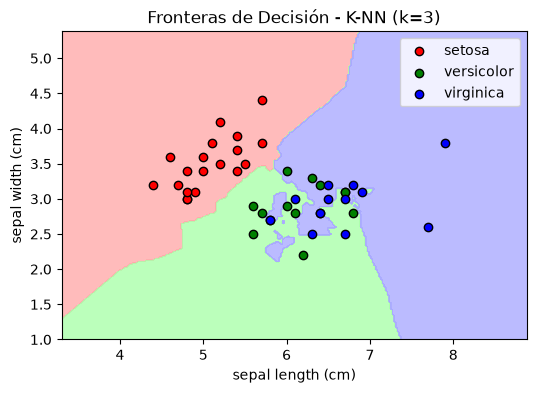

MODELO: Árbol de Decisión
Exactitud (Accuracy): 0.6666666666666666

Matriz de Confusión:
 [[18  1  0]
 [ 0  6  7]
 [ 0  7  6]]

Reporte de Clasificación:
               precision    recall  f1-score   support

      setosa       1.00      0.95      0.97        19
  versicolor       0.43      0.46      0.44        13
   virginica       0.46      0.46      0.46        13

    accuracy                           0.67        45
   macro avg       0.63      0.62      0.63        45
weighted avg       0.68      0.67      0.67        45



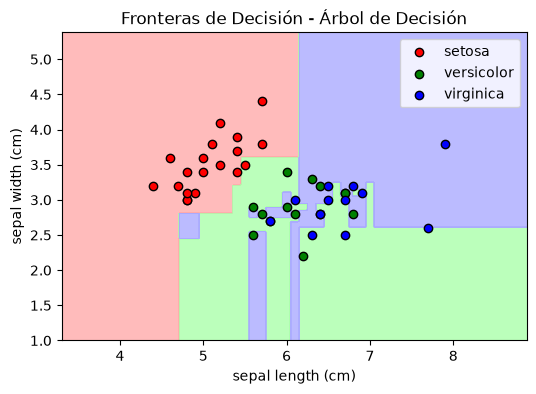

In [2]:
# Importar librerías necesarias
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from matplotlib.colors import ListedColormap

# 1. Cargar el dataset Iris
# Usamos solo 2 características (features) para poder graficar las fronteras en 2D fácilmente:
# 0: Longitud del sépalo, 1: Ancho del sépalo
iris = load_iris()
X = iris.data[:, :2] 
y = iris.target
nombres_clases = iris.target_names

# 2. Realizar la partición de datos 70% entrenamiento y 30% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Definir los tres clasificadores solicitados
clasificadores = {
    "LDA": LinearDiscriminantAnalysis(),
    "K-NN (k=3)": KNeighborsClassifier(n_neighbors=3),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42)
}

# Configuración para graficar las fronteras
h = 0.02  # paso de la malla
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Colores para las regiones y los puntos
cmap_fondo = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_puntos = ['red', 'green', 'blue']

# 4. Entrenar, evaluar métricas y graficar cada modelo
for nombre, modelo in clasificadores.items():
    print(f"="*40)
    print(f"MODELO: {nombre}")
    print(f"="*40)
    
    # Entrenar el modelo
    modelo.fit(X_train, y_train)
    
    # Predecir sobre el conjunto de prueba
    y_pred = modelo.predict(X_test)
    
    # Mostrar métricas
    print("Exactitud (Accuracy):", accuracy_score(y_test, y_pred))
    print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred))
    print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred, target_names=nombres_clases))
    
    # Graficar las fronteras de decisión
    plt.figure(figsize=(6, 4))
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, cmap=cmap_fondo, alpha=0.8)
    
    # Graficar los puntos de prueba
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X_test[y_test == cl, 0], y=X_test[y_test == cl, 1],
                    c=cmap_puntos[idx], marker='o', label=nombres_clases[cl], edgecolor='k')
        
    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])
    plt.title(f"Fronteras de Decisión - {nombre}")
    plt.legend()
    plt.show()

# Ejercicio: Comparación de clasificadores sobre el conjunto Iris

## Objetivo

Este ejercicio tiene como finalidad comparar tres algoritmos de clasificación supervisada sobre el dataset Iris y evaluar cómo cada uno separa las clases en un espacio bidimensional.

Se utilizan únicamente dos variables del conjunto de datos:
- Longitud del sépalo
- Ancho del sépalo

Con esto, es posible visualizar las fronteras de decisión en un plano 2D y analizar de manera intuitiva el comportamiento de cada modelo.

## Dataset utilizado

El conjunto Iris contiene 150 observaciones de flores, repartidas en 3 clases:
- Setosa
- Versicolor
- Virginica

Cada registro incluye medidas de diferentes partes de la flor, y para este ejercicio se seleccionan únicamente dos características para la visualización.

## Metodología

1. Se carga el dataset Iris.
2. Se seleccionan dos características para trabajar en 2 dimensiones.
3. Se divide el conjunto en entrenamiento y prueba usando una partición 70/30.
4. Se entrenan tres modelos:
   - LDA
   - K-NN con k = 3
   - Árbol de Decisión
5. Se evalúan con métricas como la exactitud, la matriz de confusión y el reporte de clasificación.
6. Se grafican las fronteras de decisión para comparar visualmente la forma en que cada algoritmo separa las clases.

## Modelos comparados

### 1. LDA (Linear Discriminant Analysis)
Es un método basado en análisis discriminante que busca separar las clases mediante fronteras lineales. Es útil cuando las clases presentan una separación clara y relativamente lineal.

#### ¿Cuándo se usa?
Se usa cuando las clases están claramente separadas por límites lineales y cuando la distribución de los datos se comporta de forma aproximadamente normal.

#### ¿Cuándo no se usa?
No se usa cuando las fronteras reales entre clases son curvas, complejas o no lineales, porque en esos casos LDA puede quedar corto.

### 2. K-NN (K-Nearest Neighbors)
Este algoritmo clasifica un punto según los vecinos más cercanos. Su ventaja es que puede adaptarse mejor a patrones no lineales, aunque puede ser más sensible a la distribución de los datos.

#### ¿Cuándo se usa?
Se usa cuando las relaciones locales son importantes y cuando no hay una regla geométrica simple que describa las clases.

#### ¿Cuándo no se usa?
No se usa en datasets muy grandes o con muchas características, porque la distancia a todos los vecinos puede hacer que el algoritmo sea lento y costoso en memoria.

### 3. Árbol de Decisión
Representa decisiones mediante reglas jerárquicas. Es fácil de interpretar y suele funcionar bien cuando las relaciones entre variables son razonablemente simples.

#### ¿Cuándo se usa?
Se usa cuando se quiere un modelo interpretable y cuando se desea entender paso a paso cómo se toma la decisión.

#### ¿Cuándo no se usa?
No se usa cuando el modelo se vuelve demasiado complejo y sobreajusta los datos, o cuando se necesita una frontera muy suave y continua.

## ¿Qué se evalúa?

Durante la ejecución del ejercicio se observan los siguientes indicadores:

- Exactitud general del modelo
- Matriz de confusión
- Reporte por clase
- Visualización de regiones de decisión

Estos resultados permiten comparar no solo la precisión, sino también la forma geométrica de las fronteras y la facilidad de interpretación del modelo.

## Analogía

Imagina que cada algoritmo es un tipo de detective tratando de separar a tres pandillas en una ciudad:

- LDA es el detective tradicional: dibuja líneas rectas y ordenadas y cree que la ciudad puede dividirse con rutas claras.
- K-NN es el detective de barrio: mira a los vecinos más cercanos y decide según el entorno inmediato.
- Árbol de Decisión es el detective burocrático: hace preguntas ordenadas del tipo “si la medida es mayor que X, entonces va a una clase”.

Cada uno toma decisiones distintas, y por eso las fronteras de separación que dibujan son diferentes.

## Interpretación esperada

- El modelo LDA suele generar fronteras rectas y bien definidas.
- K-NN tiende a producir límites más flexibles y locales.
- El Árbol de Decisión suele dibujar particiones más rígidas y en bloques.

La comparación visual ayuda a comprender cómo cada algoritmo toma decisiones y qué tipo de estructuras de datos maneja mejor.

## Conclusión

Este ejercicio permite analizar de forma práctica cómo diferentes algoritmos de clasificación resuelven un mismo problema y cómo la elección del modelo influye en la precisión y en la forma de las decisiones tomadas. Es una introducción útil a la comparación de modelos en aprendizaje supervisado.


## ¿Cómo funciona el código?

Este programa trabaja con un dataset que contiene observaciones de flores, específicamente el conjunto Iris. Cada fila del dataset representa una flor y cada columna representa una característica de esa flor, como:

- longitud del sépalo
- ancho del sépalo
- longitud del pétalo
- ancho del pétalo

Además, el dataset incluye la etiqueta o clase a la que pertenece cada flor:

- Setosa
- Versicolor
- Virginica

En otras palabras, el código importa información de imágenes o mediciones de flores y la organiza en una tabla donde cada flor tiene sus características y su clase correcta.

### ¿Qué hace con esos datos?

Primero, toma solo dos variables para poder graficar el problema en 2 dimensiones:

- X = iris.data[:, :2]

Esto significa que se utilizarán dos columnas del dataset: la longitud y el ancho del sépalo. Con estas dos variables, el algoritmo puede representar el problema en un plano cartesiano.

Luego, separa los datos en dos grupos:

- 70% para entrenar los modelos
- 30% para probarlos después a ciegas

Esto se hace con:

- X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Aquí:

- X_train y y_train: datos y etiquetas usados para entrenar
- X_test y y_test: datos y etiquetas reservados para evaluar la calidad del modelo

La idea es entrenar cada algoritmo con un conjunto de datos y luego comprobar si puede clasificar correctamente las flores que no vio antes.

### ¿Qué se evalúa después?

El código entrena tres modelos distintos:

- LDA
- K-NN
- Árbol de Decisión

Luego calcula métricas como:

- exactitud (accuracy)
- matriz de confusión
- reporte de clasificación

Estas métricas muestran cuántas flores fueron clasificadas correctamente y en qué casos se confundieron entre clases.

### ¿Qué significa “a ciegas”?

Cuando se habla de probar el modelo con el 30% restante, se refiere a que el algoritmo no ha visto esos datos durante el entrenamiento. Es decir, evalúa su capacidad para generalizar y reconocer nuevas flores con base en lo aprendido.

Finalmente, el código genera gráficos con las fronteras de decisión, que muestran cómo cada algoritmo divide el espacio para separar las tres especies de flores.

En resumen, el programa importa un dataset de flores, selecciona dos variables, entrena varios clasificadores, y luego compara cómo cada uno se desempeña en datos nuevos y no vistos.